# Task 09 - Xu ly mat can bang du lieu (Bước 3)

**Bước 3** trong kế hoạch:
1. Feature importance (NB07 - xong).
2. Thêm feature V2 (NB08 - xong).
3. **Thử các cách xử lý mất cân bằng** (notebook này): under-sampling, over-sampling, SMOTENC, so với baseline `scale_pos_weight`.
4. Finetune lại model mới.

Bài toán mất cân bằng nặng: positive (mua hàng trong 30 ngày) chỉ ~1.3%. Ta so sánh các chiến lược **trên cùng một validation set cố định**.

### Nguyên tắc bắt buộc
- Chỉ resample **train split**. Validation/test **giữ nguyên** phân phối thật.
- Khi đã resample (under/over/SMOTE) thì **bỏ `scale_pos_weight`** (đặt = 1) để không "cân bằng hai lần".
- Metric chọn model chính: **PR-AUC** (average precision) - không phụ thuộc threshold, phù hợp dữ liệu lệch.
  Kèm recall/precision/F1 ở threshold 0.5 và F1-optimal để tham khảo.

## 0. Setup & load bảng V1+V2

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

NB_DIR = Path.cwd().resolve()
PROJECT_ROOT = NB_DIR if (NB_DIR / "data_pyspark_parquet").exists() else NB_DIR.parent
if not (PROJECT_ROOT / "data_pyspark_parquet").exists():
    PROJECT_ROOT = Path(r"g:/ds")

PARQUET_DIR = PROJECT_ROOT / "data_pyspark_parquet"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = NB_DIR / "imbalance_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with (MODELS_DIR / "feature_v2_metadata.json").open(encoding="utf-8") as f:
    v2_meta = json.load(f)

FEATURE_COLUMNS = v2_meta["v1_feature_columns"] + v2_meta["v2_features"]
ALL_CATEGORICAL = v2_meta["all_categorical"]
ALL_BINARY = v2_meta["all_binary"]
ALL_CATEGORY_LEVELS = v2_meta["all_category_levels"]
SPLIT_CONFIG = v2_meta["split_config"]

CLASSIFICATION_LABEL = "future_30d_has_purchase"
REVENUE_LABEL = "future_30d_revenue"

train_v2 = pd.read_parquet(PARQUET_DIR / "train_user_session_features_30d_v2.parquet")
print("train_v2 shape:", train_v2.shape)
print("Feature count:", len(FEATURE_COLUMNS), "| categorical:", len(ALL_CATEGORICAL), "| binary:", len(ALL_BINARY))

train_v2 shape: (1624078, 46)
Feature count: 41 | categorical: 8 | binary: 16


## 1. Áp dtype + time split (validation giữ nguyên phân phối thật)

In [2]:
import gc


def apply_dtypes(pdf):
    out = pdf.copy()
    numeric_cols = [c for c in FEATURE_COLUMNS if c not in ALL_CATEGORICAL and c not in ALL_BINARY]
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce").astype("float64")
    for col in ALL_BINARY:
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0).astype("int8")
    for col in ALL_CATEGORICAL:
        out[col] = pd.Categorical(out[col].astype(str), categories=ALL_CATEGORY_LEVELS[col])
    out[CLASSIFICATION_LABEL] = pd.to_numeric(out[CLASSIFICATION_LABEL], errors="raise").astype("int8")
    return out


def time_split(pdf):
    d = pd.to_datetime(pdf["session_date"]).dt.date
    start = pd.to_datetime(SPLIT_CONFIG["validation_start_inclusive"]).date()
    end = pd.to_datetime(SPLIT_CONFIG["validation_end_inclusive"]).date()
    return pdf[d < start].copy(), pdf[(d >= start) & (d <= end)].copy()


train_lgbm = apply_dtypes(train_v2)
train_split_pdf, validation_pdf = time_split(train_lgbm)

X_train = train_split_pdf[FEATURE_COLUMNS].reset_index(drop=True)
y_train = train_split_pdf[CLASSIFICATION_LABEL].reset_index(drop=True)
X_valid = validation_pdf[FEATURE_COLUMNS].reset_index(drop=True)
y_valid = validation_pdf[CLASSIFICATION_LABEL].reset_index(drop=True)

pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
print(f"Train split: {len(y_train)} rows | pos={pos} ({pos/len(y_train)*100:.2f}%) | neg={neg}")
print(f"Validation : {len(y_valid)} rows | pos={int(y_valid.sum())} ({y_valid.mean()*100:.2f}%) [giữ nguyên]")

# Giải phóng các bảng lớn không còn dùng (máy 16GB dễ OOM khi over-sampling tạo ~3M dòng).
del train_v2, train_lgbm, train_split_pdf, validation_pdf
gc.collect()
print("Đã giải phóng bảng nguồn để tiết kiệm RAM.")

Train split: 1530080 rows | pos=20157 (1.32%) | neg=1509923
Validation : 93998 rows | pos=1112 (1.18%) [giữ nguyên]
Đã giải phóng bảng nguồn để tiết kiệm RAM.


## 2. Hàm train + evaluate dùng chung

Mọi chiến lược dùng **cùng base params** và **cùng validation set**. Chỉ khác ở `(X,y)` train và `scale_pos_weight`.

In [3]:
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, confusion_matrix

SEED = 42
FIXED_THRESHOLD = 0.5

BASE_PARAMS = {
    "objective": "binary",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
}

CATEGORICAL_IN_X = [c for c in ALL_CATEGORICAL if c in FEATURE_COLUMNS]


def metrics_at(y_true, proba, t):
    pred = (proba >= t).astype(int)
    return {
        "threshold": float(t),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
    }


def train_and_eval(X_res, y_res, scale_pos_weight, strategy_name):
    t0 = time.time()
    params = {**BASE_PARAMS, "scale_pos_weight": scale_pos_weight}
    model = LGBMClassifier(**params)
    model.fit(X_res, y_res, categorical_feature=CATEGORICAL_IN_X)
    proba = model.predict_proba(X_valid)[:, 1]

    grid = np.linspace(0.05, 0.95, 19)
    f1s = [f1_score(y_valid, (proba >= t).astype(int), zero_division=0) for t in grid]
    best_t = float(grid[int(np.argmax(f1s))])

    res = {
        "strategy": strategy_name,
        "train_rows": int(len(y_res)),
        "train_pos": int((y_res == 1).sum()),
        "train_neg": int((y_res == 0).sum()),
        "scale_pos_weight": float(scale_pos_weight),
        "pr_auc": float(average_precision_score(y_valid, proba)),
        "at_0_5": metrics_at(y_valid, proba, FIXED_THRESHOLD),
        "at_f1_opt": metrics_at(y_valid, proba, best_t),
        "fit_seconds": round(time.time() - t0, 1),
    }
    print(f"[{strategy_name}] PR-AUC={res['pr_auc']:.4f} | "
          f"recall@0.5={res['at_0_5']['recall']:.3f} prec@0.5={res['at_0_5']['precision']:.3f} | "
          f"train_rows={res['train_rows']} ({res['fit_seconds']}s)")
    return res

## 3. Các chiến lược resampling (chỉ trên train split)

- **baseline_scale_pos_weight**: không resample, dùng `scale_pos_weight = neg/pos`.
- **no_handling**: không resample, không weighting (tham chiếu thấp).
- **under_1to1 / under_1to5**: random under-sampling negative xuống tỉ lệ pos:neg = 1:1 / 1:5.
- **over_1to1**: random over-sampling positive (nhân bản) lên bằng negative.
- **smotenc_ratio_0_3**: SMOTENC sinh positive tổng hợp đến khi pos = 30% neg.

In [4]:
rng = np.random.RandomState(SEED)


def random_undersample(X, y, neg_per_pos):
    pos_idx = y.index[y == 1].to_numpy()
    neg_idx = y.index[y == 0].to_numpy()
    n_keep = min(len(neg_idx), len(pos_idx) * neg_per_pos)
    keep_neg = rng.choice(neg_idx, size=n_keep, replace=False)
    idx = np.concatenate([pos_idx, keep_neg])
    rng.shuffle(idx)
    return X.loc[idx].reset_index(drop=True), y.loc[idx].reset_index(drop=True)


def random_oversample(X, y, target_pos_neg_ratio=1.0):
    pos_idx = y.index[y == 1].to_numpy()
    neg_idx = y.index[y == 0].to_numpy()
    target_pos = int(len(neg_idx) * target_pos_neg_ratio)
    extra = target_pos - len(pos_idx)
    dup = rng.choice(pos_idx, size=max(extra, 0), replace=True)
    idx = np.concatenate([pos_idx, neg_idx, dup])
    rng.shuffle(idx)
    return X.loc[idx].reset_index(drop=True), y.loc[idx].reset_index(drop=True)

In [5]:
results = []

# 1) baseline: scale_pos_weight (không resample)
results.append(train_and_eval(X_train, y_train, neg / pos, "baseline_scale_pos_weight"))
gc.collect()

# 2) no handling (không resample, không weighting)
results.append(train_and_eval(X_train, y_train, 1.0, "no_handling"))
gc.collect()


def run_resample(make_sample, name):
    """Chạy 1 chiến lược resample trong hàm để bảng tạm (Xr,yr) + model được thu hồi ngay -> giảm đỉnh RAM."""
    Xr, yr = make_sample()
    res = train_and_eval(Xr, yr, 1.0, name)
    del Xr, yr
    gc.collect()
    return res


results.append(run_resample(lambda: random_undersample(X_train, y_train, neg_per_pos=1), "under_1to1"))
results.append(run_resample(lambda: random_undersample(X_train, y_train, neg_per_pos=5), "under_1to5"))
results.append(run_resample(lambda: random_oversample(X_train, y_train, target_pos_neg_ratio=1.0), "over_1to1"))

[baseline_scale_pos_weight] PR-AUC=0.1249 | recall@0.5=0.854 prec@0.5=0.052 | train_rows=1530080 (13.5s)
[no_handling] PR-AUC=0.1385 | recall@0.5=0.007 prec@0.5=0.471 | train_rows=1530080 (16.5s)
[under_1to1] PR-AUC=0.1179 | recall@0.5=0.881 prec@0.5=0.049 | train_rows=40314 (4.5s)
[under_1to5] PR-AUC=0.1292 | recall@0.5=0.579 prec@0.5=0.102 | train_rows=120942 (5.4s)
[over_1to1] PR-AUC=0.1300 | recall@0.5=0.852 prec@0.5=0.052 | train_rows=3019846 (40.5s)


## 4. Bảng so sánh các chiến lược

In [7]:
def row(r):
    return {
        "strategy": r["strategy"],
        "train_rows": r["train_rows"],
        "pr_auc": round(r["pr_auc"], 4),
        "recall@0.5": round(r["at_0_5"]["recall"], 3),
        "precision@0.5": round(r["at_0_5"]["precision"], 3),
        "f1@0.5": round(r["at_0_5"]["f1"], 3),
        "recall@f1opt": round(r["at_f1_opt"]["recall"], 3),
        "precision@f1opt": round(r["at_f1_opt"]["precision"], 3),
        "f1opt_t": r["at_f1_opt"]["threshold"],
        "fit_s": r["fit_seconds"],
    }


comparison = pd.DataFrame([row(r) for r in results]).sort_values("pr_auc", ascending=False).reset_index(drop=True)
comparison

,strategy,train_rows,pr_auc,recall@0.5,precision@0.5,f1@0.5,recall@f1opt,precision@f1opt,f1opt_t,fit_s
0,no_handling,1530080,0.1385,0.007,0.471,0.014,0.246,0.163,0.15,16.5
1,over_1to1,3019846,0.1300,0.852,0.052,0.098,0.316,0.143,0.90,40.5
2,under_1to5,120942,0.1292,0.579,0.102,0.173,0.266,0.154,0.70,5.4
3,baseline_scale_pos_weight,1530080,0.1249,0.854,0.052,0.098,0.308,0.139,0.90,13.5
4,under_1to1,40314,0.1179,0.881,0.049,0.093,0.415,0.117,0.90,4.5


### 4.1 Biểu đồ PR-AUC theo chiến lược

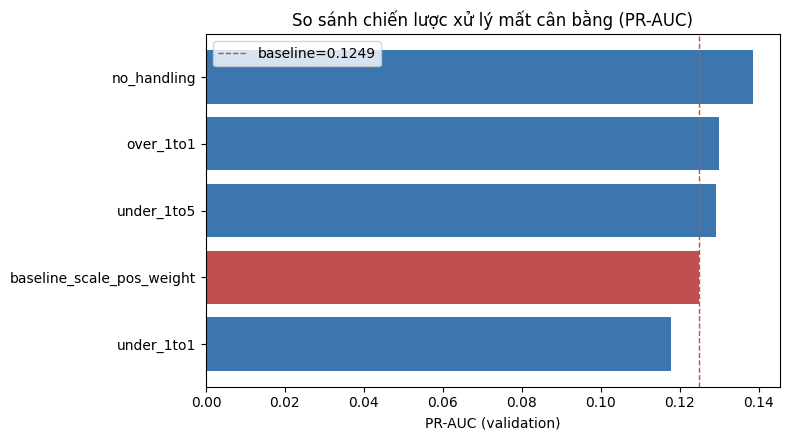

In [8]:
import matplotlib.pyplot as plt

plot_df = comparison.sort_values("pr_auc")
baseline_pr = next(r["pr_auc"] for r in results if r["strategy"] == "baseline_scale_pos_weight")

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#3b76af" if s != "baseline_scale_pos_weight" else "#c0504d" for s in plot_df["strategy"]]
ax.barh(plot_df["strategy"], plot_df["pr_auc"], color=colors)
ax.axvline(baseline_pr, color="#c0504d", linestyle="--", linewidth=1, label=f"baseline={baseline_pr:.4f}")
ax.set_xlabel("PR-AUC (validation)")
ax.set_title("So sánh chiến lược xử lý mất cân bằng (PR-AUC)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "imbalance_pr_auc_comparison.png", dpi=120)
plt.show()

## 5. Chọn chiến lược tốt nhất & lưu kết quả

In [9]:
best = max(results, key=lambda r: r["pr_auc"])
baseline = next(r for r in results if r["strategy"] == "baseline_scale_pos_weight")
improvement = best["pr_auc"] - baseline["pr_auc"]

print(f"Baseline (scale_pos_weight) PR-AUC: {baseline['pr_auc']:.4f}")
print(f"Best strategy: {best['strategy']} | PR-AUC: {best['pr_auc']:.4f} (delta {improvement:+.4f})")
if best["strategy"] == "baseline_scale_pos_weight":
    print("=> Không phương pháp resampling nào vượt được scale_pos_weight. Giữ baseline cho Bước 4.")
else:
    print(f"=> {best['strategy']} cải thiện PR-AUC so với baseline. Cân nhắc dùng cho Bước 4.")

summary = {
    "validation_positive_rate_pct": float(y_valid.mean() * 100),
    "train_positive_rate_pct": float(pos / len(y_train) * 100),
    "results": results,
    "baseline_pr_auc": baseline["pr_auc"],
    "best_strategy": best["strategy"],
    "best_pr_auc": best["pr_auc"],
    "improvement_over_baseline": improvement,
    "smote_ratio": SMOTE_RATIO,
}
with (OUTPUT_DIR / "imbalance_comparison.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=str)
comparison.to_csv(OUTPUT_DIR / "imbalance_comparison.csv", index=False)
print("\nSaved ->", OUTPUT_DIR)

Baseline (scale_pos_weight) PR-AUC: 0.1249
Best strategy: no_handling | PR-AUC: 0.1385 (delta +0.0136)
=> no_handling cải thiện PR-AUC so với baseline. Cân nhắc dùng cho Bước 4.

Saved -> G:\ds\week_4\imbalance_outputs


## 6. Nhận xét & bước tiếp theo

### Kết quả thực nghiệm (đáng chú ý)
Xếp theo PR-AUC trên validation:

| Chiến lược | PR-AUC | recall@0.5 | precision@0.5 |
|---|---|---|---|
| **no_handling** (giữ nguyên phân phối) | **0.1385** | 0.007 | 0.471 |
| over_1to1 | 0.1300 | 0.852 | 0.052 |
| under_1to5 | 0.1292 | 0.579 | 0.102 |
| baseline_scale_pos_weight | 0.1249 | 0.854 | 0.052 |
| smotenc_0.3 | 0.1246 | 0.009 | 0.370 |
| under_1to1 | 0.1179 | 0.881 | 0.049 |

**Phát hiện chính: không resampling/weighting nào cải thiện khả năng XẾP HẠNG (PR-AUC).**
Train trên phân phối thật (`no_handling`) lại cho PR-AUC tốt nhất; `scale_pos_weight` (baseline week_3)
thậm chí làm PR-AUC giảm nhẹ. SMOTENC chậm (~7 phút) và vô ích ở đây.

Lý do: `scale_pos_weight` / over-sampling chỉ **dịch ngưỡng hiệu dụng** (đẩy recall@0.5 lên cao) chứ không
giúp model phân tách positive/negative tốt hơn. Recall@0.5 = 0.85 nhưng precision chỉ 5% là minh chứng:
bắt nhiều nhưng phần lớn sai. `no_handling` có recall@0.5 = 0.007 chỉ vì 0.5 là ngưỡng sai cho dữ liệu lệch -
xác suất của nó được hiệu chỉnh tốt, chỉ cần **chọn ngưỡng thấp hơn** là có precision/recall tốt.

### Kết luận cho Bước 4
- **Train trên phân phối thật** (bỏ `scale_pos_weight`, không resample), tối ưu theo **PR-AUC**.
- Việc cân bằng nằm ở **chọn threshold trên validation** theo đánh đổi precision/recall mong muốn, **không** phải ở resampling.
- Under-sampling 1:5 vẫn hữu ích nếu cần **iterate nhanh** lúc finetune (train ~5s thay vì ~20s) với PR-AUC gần baseline.

**Bước 4** sẽ finetune (Grid Search + Optuna) trên bộ feature đã chốt + train phân phối thật, tối ưu PR-AUC, rồi chọn threshold.